# London Property Radar — Model Evaluation\n\nEvaluates the trained Random Forest on a held-out test set and visualises performance.

In [3]:
#imports and setup
import os, sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sys.path.insert(0, os.path.abspath(".."))

#paths to training data and the trained model
BASE = os.path.abspath("..")
DATA_PATH = os.path.join(BASE, "data/processed/training_data.parquet")
MODEL_PATH = os.path.join(BASE, "model/rf_model.pkl")

FEATURES = ["square_meters", "bedrooms", "bathrooms", "neighborhood", "property_type"]
TARGET = "price"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
print("Loaded.")

Loaded


In [4]:
#load data and model - use the same random_state=42 as training so the test split is identical
df = pd.read_parquet(DATA_PATH)
model = joblib.load(MODEL_PATH)

X = df[FEATURES]
y = df[TARGET]

#80/20 train/test split matching the split used during training
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)
residuals = y_test.values - y_pred

#compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs(residuals / y_test.values)) * 100
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"Test set : {len(y_test):,} rows")
print(f"R2       : {r2:.4f}")
print(f"MAE      : £{mae:,.0f}")
print(f"RMSE     : £{rmse:,.0f}")
print(f"MAPE     : {mape:.1f}%")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking cod

Test set : 200 rows
R²: 0.8866
MAE: £234,364
RMSE: £302,194
MAPE: 14.4%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 1. Actual vs Predicted

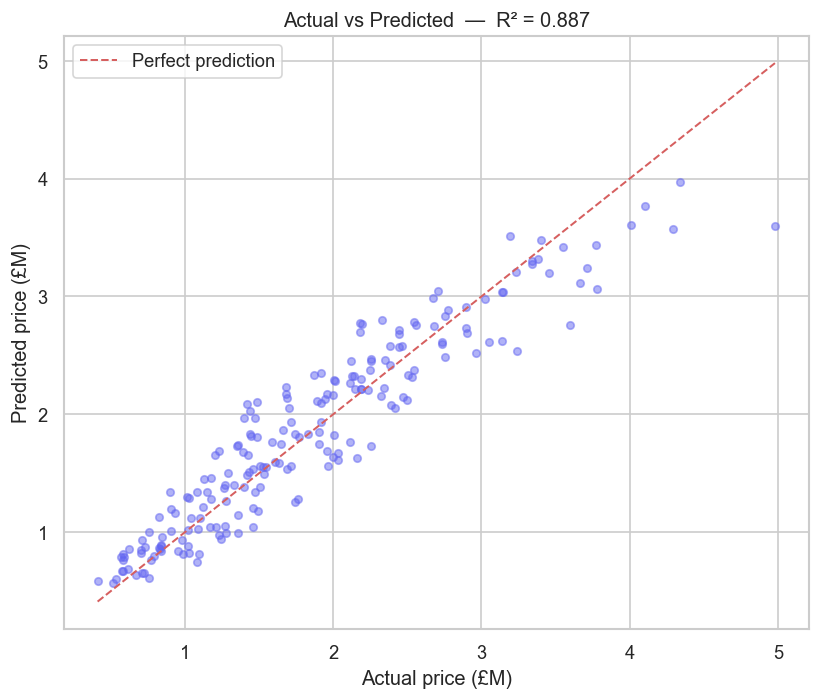

In [3]:
#scatter plot of actual vs predicted prices with a perfect prediction reference line
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="#6366f1")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect prediction")
ax.set_xlabel("Actual price (£)")
ax.set_ylabel("Predicted price (£)")
ax.set_title(f"Actual vs Predicted -- R2 = {r2:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Feature Importances

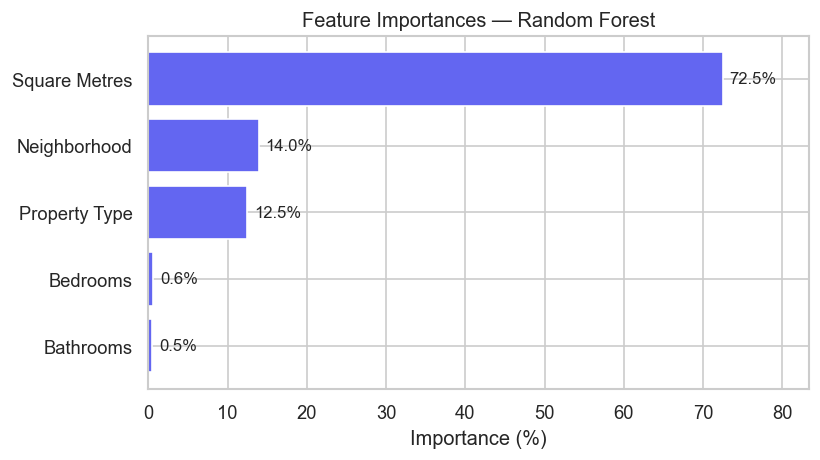

In [5]:
#extract feature importances from the trained random forest and plot as a horizontal bar chart
importances = model.named_steps["rf"].feature_importances_
feat_df = pd.DataFrame({
    "feature": ["Square Metres", "Bedrooms", "Bathrooms", "Neighborhood", "Property Type"],
    "importance": importances,
}).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(feat_df["feature"], feat_df["importance"] * 100, color="#6366f1", edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_xlabel("Importance (%)")
ax.set_title("Feature Importances - Random Forest")
ax.set_xlim(0, feat_df["importance"].max() * 115)
plt.tight_layout()
plt.show()

## 3. Error by Neighborhood

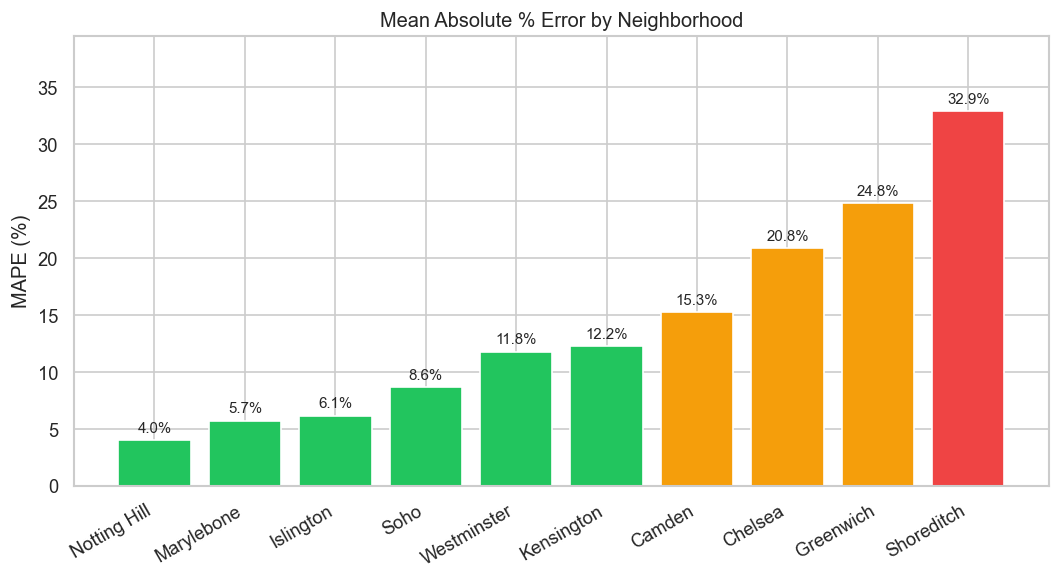

In [6]:
#calculate MAE and MAPE per neighbourhood on the test set
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred
results["abs_error"] = np.abs(residuals)
results["pct_error"] = np.abs(residuals / y_test.values) * 100
by_hood = (results.groupby("neighborhood")
           .agg(mae=("abs_error", "mean"), mape=("pct_error", "mean"), n=("actual", "count"))
           .sort_values("mape"))
#colour bars: green under 15%, amber under 25%, red above
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#22c55e" if v < 15 else "#f59e0b" if v < 25 else "#ef4444" for v in by_hood["mape"]]
bars = ax.bar(by_hood.index, by_hood["mape"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_ylabel("MAPE (%)")
ax.set_title("Mean Absolute % Error by Neighborhood")
ax.set_ylim(0, by_hood["mape"].max() * 1.2)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(by_hood[["mae", "mape", "n"]].rename(columns={"mae": "MAE (£)", "mape": "MAPE (%)", "n": "Test rows"})
      .style.format({"MAE (£)": "£{:,.0f}", "MAPE (%)": "{:.1f}%"}))

## 4. Price Distribution — Actual vs Predicted

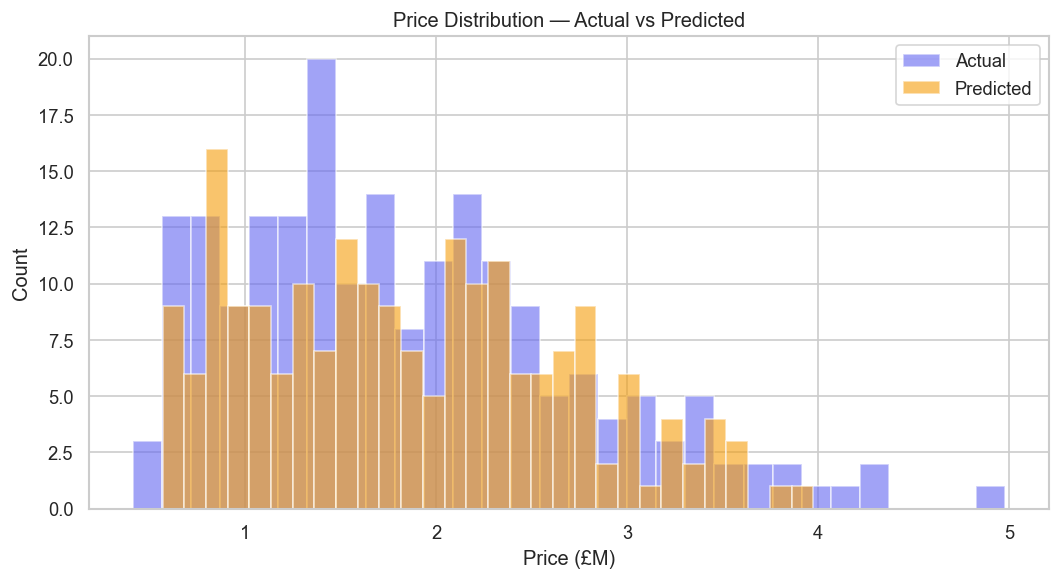

In [7]:
#overlapping histogram showing how closely the predicted price distribution matches actual
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_test, bins=30, alpha=0.6, label="Actual", color="#6366f1", edgecolor="white")
ax.hist(y_pred, bins=30, alpha=0.6, label="Predicted", color="#f59e0b", edgecolor="white")
ax.set_xlabel("Price (£)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution - Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()